### PSMNIST with LMU

In [2]:
from __future__ import annotations
from typing import Dict, Any

import torch
import os
from pathlib import Path

from psmnist_task import PSMNISTTask
from src.train_utils.trainer import Trainer
from src.models.v2.build_model import BlockConfig

### Configuration
We define a set of hyperparameters and configurations for the training process.
This includes data paths, batch sizes, learning rates, and model-specific parameters.
A `create_block_cfg_ctor` function is defined to generate model block configurations dynamically,
allowing for easy switching between LMU and S4 models.

In [3]:
def create_block_cfg_ctor(kind: str, dropout: float, mlp_ratio: float, droppath_final: float,
                          layerscale_init: float, residual_gain: float, pool: str, **kwargs):
    """Create a block config constructor with the given hyperparameters."""
    def block_cfg_ctor(theta: int) -> BlockConfig:
        return BlockConfig(
            kind=kind,
            memory_size=256,
            theta=theta,
            dropout=dropout,
            mlp_ratio=mlp_ratio,
            droppath_final=droppath_final,
            layerscale_init=layerscale_init,
            residual_gain=residual_gain,
            pool=pool,
            **kwargs
        )
    return block_cfg_ctor


In [4]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
data_root = str(project_root / "src" / "datasets" / "psmnist" / "data")

args: Dict[str, Any] = {
    # data
    "data_root": data_root,
    "batch": 128,
    "data_loader_kwargs": {
        "num_workers": 0,
        "permutation_seed": 42,
        "normalize": "standard",
        "pin_memory": False,
        "persistent_workers": False,
    },

    # training
    "epochs": 50,
    "lr": 1e-3,
    "wd": 1e-4,
    "amp": False,
    "save_dir": "./runs/psmnist_lmu_task",
    "warmup_epochs": 5,
    "patience": 5,
    "min_delta": 0.001,
    "early_key": "accuracy",

    # model scaffold
    "d_model": 128,
    "depth": 2,
    "dropout": 0.1,  # ⬇️ Less dropout for simpler task
    "mlp_ratio": 2.0,
    "droppath_final": 0.0,
    "layerscale_init": 0.0,
    "residual_gain": 1.0,
    "pool": "mean",
}

args["block_cfg_ctor"] = create_block_cfg_ctor(
    kind="lmu",
    dropout=args["dropout"],
    mlp_ratio=args["mlp_ratio"],
    droppath_final=args["droppath_final"],
    layerscale_init=args["layerscale_init"],
    residual_gain=args["residual_gain"],
    pool=args["pool"],
)

if torch.backends.mps.is_available():
    args["device"] = torch.device("mps")
    print("🚀 Using MPS")
elif torch.cuda.is_available():
    args["device"] = torch.device("cuda")
else:
    args["device"] = torch.device("cpu")
    args["amp"] = False

🚀 Using MPS


### Training
With the configuration set up, we can now instantiate the `PSMNISTTask` and the `Trainer`.
The `fit` method on the trainer will start the training process, which includes training,
validation, and saving the best model based on the validation accuracy.

In [5]:
import matplotlib.pyplot as plt

def plot_history(history):

    plt.figure(figsize=(12, 5))

    # Plot training and validation loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Plot training and validation accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy')
    plt.plot(history['val_acc'], label='Val Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
task = PSMNISTTask()

if torch.backends.mps.is_available():
    torch.mps.set_per_process_memory_fraction(0.9)
    os.environ["PYTORCH_MPS_HIGH_WATERMARK_RATIO"] = "0.0"

trainer = Trainer(args=args, task=task)

best_metric, ckpt_path = trainer.fit()
print(f"Done. Best {trainer.early_key}={best_metric:.4f} @ {ckpt_path}")

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
✅ Loaded checkpoint from epoch 24
📊 Val metrics: {'loss': 0.14989372519329192, 'time_s': 29.88077812499978, 'acc': 0.9624}


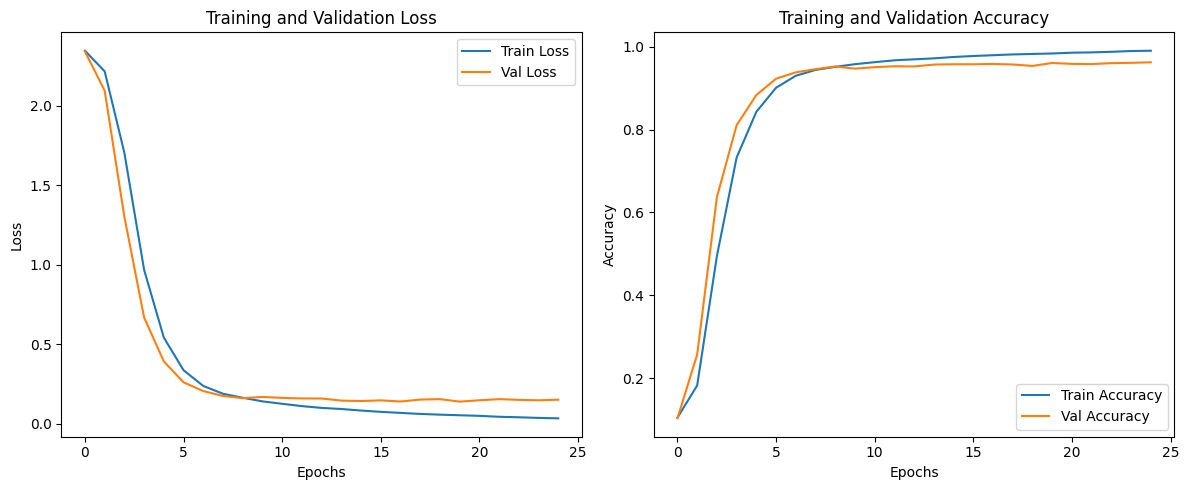

In [7]:
from src.utils.checkpoint import load_trainer_from_checkpoint

trainer = load_trainer_from_checkpoint(
    checkpoint_path=args["save_dir"] + "/best.pt",
    args=args,
    task=PSMNISTTask(),
)

history = trainer.history

plot_history(history)

### Evaluation
After training, we can evaluate the best model on the test set.
We load the best model from the checkpoint and then run the evaluation.
The results, including accuracy, are printed.

PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)
✅ Loaded checkpoint from epoch 24
📊 Val metrics: {'loss': 0.14989372519329192, 'time_s': 29.88077812499978, 'acc': 0.9624}
PS-MNIST Loaders Created:
  Train: 60000 samples, 468 batches
  Test:  10000 samples, 79 batches
  Permutation seed: 42
  Sequence length: 784 (28×28)
  Classes: 10 (digits 0-9)


Evaluating on test set: 100%|██████████| 79/79 [00:14<00:00,  5.50it/s]



TEST SET RESULTS:
Accuracy: 0.9624
Class 00: 0.9888
Class 01: 0.9806
Class 02: 0.9651
Class 03: 0.9495
Class 04: 0.9735
Class 05: 0.9462
Class 06: 0.9509
Class 07: 0.9660
Class 08: 0.9579
Class 09: 0.9415


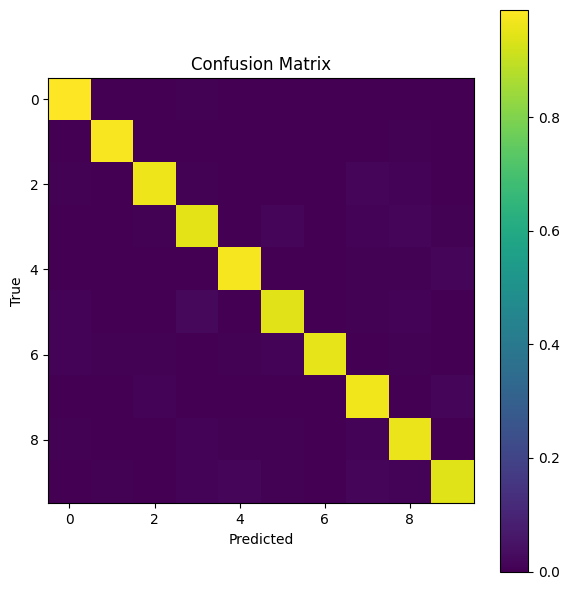

In [8]:
from src.notebooks.psmnist.psmnist_eval import evaluate_best_model, print_evaluation_results

logits_test, labels_test = evaluate_best_model(
    args=args,
    task=PSMNISTTask(),
    best_model_path=f"{args['save_dir']}/best.pt",
)

print_evaluation_results(
    logits_test=logits_test,
    labels_test=labels_test,
)